# Question Sampling for Human Study (Control Questions)

Goal: select a manageable subset of questions (~100–150) from the 1K VQA control set
that are most informative for human data collection.

## Sampling Criteria

| Tier | Criterion | Rationale |
|------|-----------|-----------|
| A | **Overconfident & Wrong** | High model confidence + low accuracy = hallucination signal |
| B | **Answer Flip across variants** | Model changes answer when question is weakened = genuine linguistic sensitivity |
| C | **Cross-model consensus wrong** | All models give same wrong answer = shared corpus prior |
| D | **High degradation** | Large accuracy drop from `question` → `subject_ablated` = shortcut dependent |
| E | **Stratified by answer type** | Ensure coverage of yes/no, number, color, location, other |

Target: ~30 questions per tier, stratified by answer type, final deduplicated set of ~100–150.

In [28]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR   = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated']

# Load entity grouping from semantics
sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = sem_df.set_index('question_id')['ent'].to_dict()
print("Entity categories:", sorted(sem_df['ent'].dropna().unique()))


Entity categories: ['animal', 'food', 'object', 'other', 'person', 'place', 'product', 'text', 'vehicle']


In [29]:
def load_control(model, dataset='vqa_1k_control'):
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(filepath):
        return []
    rows = []
    with open(filepath) as f:
        for line in f:
            ex = json.loads(line)
            if 'generated_logits' not in ex:
                continue
            gt_answers = mapper.get_answers(ex['question_id'])
            output_key = 'generated_answers' if 'generated_answers' in ex else 'answers'
            ent = qid_to_ent.get(ex['question_id'], 'other')
            for ct in ex['generated_logits']:
                logits = ex['generated_logits'][ct]['content']
                token_probs = np.exp([t['logprob'] for t in logits])
                confidence = float(token_probs.mean())
                output = ex[output_key].get(ct, '')
                accuracy = vqa_accuracy(output, gt_answers) if gt_answers else None
                rows.append({
                    'model': model,
                    'question_id': ex['question_id'],
                    'control_type': ct,
                    'question_text': ex.get(ct, ''),
                    'output': output,
                    'confidence': confidence,
                    'accuracy': accuracy,
                    'ent': ent,
                    'gt_answer': gt_answers
                })
    return rows

models = [m for m in os.listdir(RESULTS_DIR)
          if os.path.exists(f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl')]
print('Models found:', models)

all_rows = []
for m in models:
    all_rows.extend(load_control(m))

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
print(f'Loaded {len(df)} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'\nEntity distribution:\n{df[df["control_type"]=="question"]["ent"].value_counts()}')


Models found: ['Qwen3-VL-32B-Instruct', 'llava-v1.6-vicuna-7b-hf', 'llava-v1.6-vicuna-13b-hf', 'llava-1.5-7b-hf', 'Qwen3-VL-4B-Instruct', 'llava-v1.6-mistral-7b-hf', 'Qwen3-VL-8B-Instruct']
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded 25215 rows | 6 models | 1000 questions

Entity distribution:
ent
object     1741
person     1168
animal      540
other       423
food        391
place       302
vehicle     261
text        131
product      86
Name: count, dtype: int64


In [ ]:
df.model.unique()

<ArrowStringArray>
[   'Qwen3-VL-32B-Instruct',  'llava-v1.6-vicuna-7b-hf',
 'llava-v1.6-vicuna-13b-hf',          'llava-1.5-7b-hf',
 'llava-v1.6-mistral-7b-hf',     'Qwen3-VL-8B-Instruct']
Length: 6, dtype: str

In [ ]:
# Aggregate per (question_id, control_type) across models
agg = df[df['model'].isin(['llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf',  'llava-v1.6-vicuna-7b-hf',   'Qwen3-VL-8B-Instruct'])].groupby(['question_id', 'control_type', 'ent']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_confidence=('confidence', 'mean'),
    n_models=('model', 'nunique'),
    outputs=('output', lambda x: list(x)),
).reset_index()

# Per question: baseline (original question) and most-weakened (subject_ablated)
baseline = agg[agg['control_type'] == 'question'][['question_id', 'mean_accuracy', 'mean_confidence', 'ent']]
baseline.columns = ['question_id', 'acc_baseline', 'conf_baseline', 'ent']
ablated = agg[agg['control_type'] == 'subject_ablated'][['question_id', 'mean_accuracy', 'mean_confidence']]
ablated.columns = ['question_id', 'acc_ablated', 'conf_ablated']

qdf = baseline.merge(ablated, on='question_id')
qdf['acc_drop']  = qdf['acc_baseline']  - qdf['acc_ablated']
qdf['conf_drop'] = qdf['conf_baseline'] - qdf['conf_ablated']   # Tier E

# Tier A — overconfident & wrong
qdf['overconfident_wrong'] = (qdf['conf_baseline'] > 0.75) & (qdf['acc_baseline'] < 0.2)

# Tier B — answer flip across control variants
flip = df.groupby(['question_id', 'model']).apply(
    lambda g: g.set_index('control_type')['output'].reindex(CONTROL_TYPES).nunique(dropna=True)
).reset_index()
flip.columns = ['question_id', 'model', 'n_unique_outputs']
flip_agg = flip.groupby('question_id')['n_unique_outputs'].mean().reset_index()
flip_agg.columns = ['question_id', 'mean_output_changes']

# Tier C — majority of models wrong on baseline (relaxed: no requirement for same answer)
consensus = (
    df[df['control_type'] == 'question']
    .groupby('question_id')
    .apply(lambda g: (g['accuracy'] < 0.2).mean())
    .reset_index()
)
consensus.columns = ['question_id', 'frac_models_wrong']
consensus['consensus_wrong'] = consensus['frac_models_wrong'] >= 0.8

qdf = qdf.merge(flip_agg, on='question_id').merge(
    consensus[['question_id', 'consensus_wrong', 'frac_models_wrong']], on='question_id'
)
qdf.head()

,question_id,acc_baseline,conf_baseline,ent,acc_ablated,conf_ablated,acc_drop,conf_drop,overconfident_wrong,mean_output_changes,consensus_wrong,frac_models_wrong
0,589013,1.000000,0.872040,other,1.000000,0.872040,0.0,0.000000,False,1.000000,False,0.000000
1,757004,0.916667,0.856617,animal,0.916667,0.863229,0.0,-0.006613,False,1.166667,False,0.000000
2,1342072,0.000000,0.698225,other,0.000000,0.708453,0.0,-0.010228,False,1.833333,True,1.000000
3,2006001,1.000000,0.901612,vehicle,1.000000,0.899090,0.0,0.002522,False,1.333333,False,0.166667
4,2521002,0.666667,0.848073,object,0.666667,0.834765,0.0,0.013308,False,1.166667,False,0.000000


=== Criterion Counts ===
A. Overconfident & Wrong (conf>0.75, acc<0.2):        35
B. Answer flip (mean unique outputs > 2):             88
C. Consensus wrong (≥80% models wrong on baseline):  63
D. High accuracy drop (acc_drop > 0.3):              158
E. High confidence drop (conf_drop > 0.05):          205
   — of which: confident→uncertain despite correct:  177

Entity distribution (all 1K questions):
ent
object     344
person     232
animal     107
other       84
food        78
place       60
vehicle     52
text        26
product     17
Name: count, dtype: int64


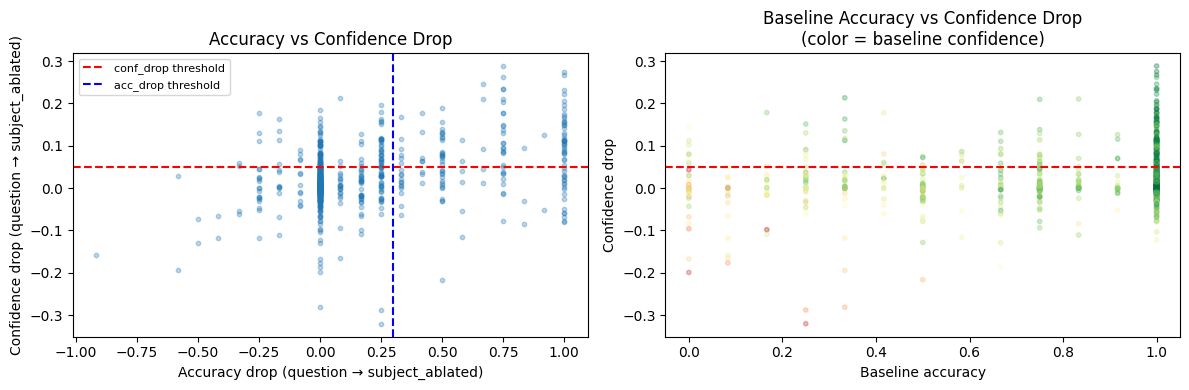

In [ ]:
print('=== Criterion Counts ===')
print(f"A. Overconfident & Wrong (conf>0.75, acc<0.2):        {qdf['overconfident_wrong'].sum()}")
print(f"B. Answer flip (mean unique outputs > 2):             {(qdf['mean_output_changes'] > 2).sum()}")
print(f"C. Consensus wrong (≥80% models wrong on baseline):  {qdf['consensus_wrong'].sum()}")
print(f"D. High accuracy drop (acc_drop > 0.3):              {(qdf['acc_drop'] > 0.3).sum()}")
print(f"E. High confidence drop (conf_drop > 0.05):          {(qdf['conf_drop'] > 0.05).sum()}")
print(f"   — of which: confident→uncertain despite correct:  "
      f"{((qdf['conf_drop'] > 0.05) & (qdf['acc_baseline'] > 0.5)).sum()}")
print()
print('Entity distribution (all 1K questions):')
print(qdf['ent'].value_counts())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(qdf['acc_drop'], qdf['conf_drop'], alpha=0.3, s=10)
axes[0].axhline(0.05, color='r', linestyle='--', label='conf_drop threshold')
axes[0].axvline(0.3, color='b', linestyle='--', label='acc_drop threshold')
axes[0].set_xlabel('Accuracy drop (question → subject_ablated)')
axes[0].set_ylabel('Confidence drop (question → subject_ablated)')
axes[0].set_title('Accuracy vs Confidence Drop')
axes[0].legend(fontsize=8)

axes[1].scatter(qdf['acc_baseline'], qdf['conf_drop'], alpha=0.3, s=10, c=qdf['conf_baseline'], cmap='RdYlGn')
axes[1].axhline(0.05, color='r', linestyle='--')
axes[1].set_xlabel('Baseline accuracy')
axes[1].set_ylabel('Confidence drop')
axes[1].set_title('Baseline Accuracy vs Confidence Drop\n(color = baseline confidence)')
plt.tight_layout()
plt.show()


In [ ]:
np.random.seed(42)

N_PER_TIER = 30

def stratified_sample(mask, n, ent_col='ent', seed=42):
    """Sample n questions from mask, stratified by entity group."""
    pool = qdf[mask].copy()
    if len(pool) == 0:
        print("  → empty pool, skipping")
        return []
    counts = pool[ent_col].value_counts(normalize=True)
    sampled = []
    for ent, frac in counts.items():
        k = max(1, round(n * frac))
        sub = pool[pool[ent_col] == ent]
        sampled.extend(sub.sample(min(k, len(sub)), random_state=seed)['question_id'].tolist())
    return list(set(sampled))[:n]

tier_A = stratified_sample(qdf['overconfident_wrong'],        N_PER_TIER)
tier_B = stratified_sample(qdf['mean_output_changes'] > 2,    N_PER_TIER)
tier_C = stratified_sample(qdf['consensus_wrong'],            N_PER_TIER)
tier_D = stratified_sample(qdf['acc_drop'] > 0.3,            N_PER_TIER)
tier_E = stratified_sample(qdf['conf_drop'] > 0.05,          N_PER_TIER)

# Combine, deduplicate, label tiers
all_sampled = {}
for qid in tier_A: all_sampled[qid] = all_sampled.get(qid, []) + ['A_overconfident_wrong']
for qid in tier_B: all_sampled[qid] = all_sampled.get(qid, []) + ['B_answer_flip']
for qid in tier_C: all_sampled[qid] = all_sampled.get(qid, []) + ['C_consensus_wrong']
for qid in tier_D: all_sampled[qid] = all_sampled.get(qid, []) + ['D_high_acc_drop']
for qid in tier_E: all_sampled[qid] = all_sampled.get(qid, []) + ['E_high_conf_drop']

sampled_df = pd.DataFrame([
    {'question_id': qid, 'tiers': '|'.join(tiers)}
    for qid, tiers in all_sampled.items()
])
sampled_df = sampled_df.merge(qdf, on='question_id')
sampled_df['n_tiers'] = sampled_df['tiers'].str.count(r'\|') + 1
sampled_df = sampled_df.sort_values('n_tiers', ascending=False)

print(f'Total unique questions selected: {len(sampled_df)}')
print(f'Questions in multiple tiers:     {(sampled_df["n_tiers"] > 1).sum()}')
print()
print('Entity distribution in sample:')
print(sampled_df['ent'].value_counts())
print()
print('Tier breakdown:')
for tier in ['A_overconfident_wrong', 'B_answer_flip', 'C_consensus_wrong', 'D_high_acc_drop', 'E_high_conf_drop']:
    print(f'  {tier}: {sampled_df["tiers"].str.contains(tier).sum()}')


Total unique questions selected: 123
Questions in multiple tiers:     25

Entity distribution in sample:
ent
object     57
person     24
animal     10
food        8
vehicle     7
place       6
other       5
text        4
product     2
Name: count, dtype: int64

Tier breakdown:
  A_overconfident_wrong: 30
  B_answer_flip: 30
  C_consensus_wrong: 30
  D_high_acc_drop: 30
  E_high_conf_drop: 30


In [31]:
# Attach question text and all model outputs for manual review
question_texts = df[df['control_type'] == 'question'][['question_id', 'question_text', 'gt_answer']].drop_duplicates('question_id') 
outputs_pivot = df[
    (df['question_id'].isin(sampled_df['question_id'])) &
    (df['control_type'] == 'question')
].pivot_table(index='question_id', columns='model', values='output', aggfunc='first').reset_index()

review_df = sampled_df.merge(question_texts, on='question_id').merge(outputs_pivot, on='question_id')

display_cols = ['question_id', 'ent', 'tiers', 'n_tiers', 'acc_baseline', 'acc_drop',
                'conf_baseline', 'frac_models_wrong', 'question_text', 'gt_answer'] + list(outputs_pivot.columns[1:])
review_df[display_cols].head(20) 

,question_id,ent,tiers,n_tiers,acc_baseline,acc_drop,conf_baseline,frac_models_wrong,question_text,gt_answer,Qwen3-VL-32B-Instruct,Qwen3-VL-8B-Instruct,llava-1.5-7b-hf,llava-v1.6-mistral-7b-hf,llava-v1.6-vicuna-13b-hf,llava-v1.6-vicuna-7b-hf
0,72096002,object,A_overconfident_wrong|B_answer_flip|C_consensu...,3,0.083333,0.083333,0.763202,0.8,Question: What part of the tablecloth flowers ...,"[ivy, flower leaves, flowers, leaves, leaves, ...",NaN,none,Center,Flowers,Roses,Tablecloth
1,13769009,place,A_overconfident_wrong|B_answer_flip|C_consensu...,3,0.000000,0.000000,0.848162,1.0,Question: What is this bathroom missing? Answe...,"[door, sink, yes, door, sink, door, door, no, ...",NaN,toilet paper,Toilet paper,Toilet paper,Toilet paper,Toilet paper
2,345711000,place,D_high_acc_drop|E_high_conf_drop,2,0.750000,0.500000,0.754743,0.2,Question: Which direction is E 42 St? Answer t...,"[to right, right, right, right, east, east, ea...",NaN,east,Right,Left,Right,Right
3,6712002,place,B_answer_flip|D_high_acc_drop,2,1.000000,0.833333,0.881320,0.0,Question: What color is the house? Answer the ...,"[blue, blue, white, blue, white, blue, blue, b...",NaN,blue,Blue,Blue,Blue,Blue
4,291990001,text,D_high_acc_drop|E_high_conf_drop,2,0.750000,0.750000,0.907725,0.0,Question: What street is this? Answer the ques...,"[35th ave, 35th ave, 35th avenue, 35th, 35 ave...",NaN,35th avenue,35th ave,35th ave,35th,35th ave
5,124601004,food,B_answer_flip|D_high_acc_drop,2,1.000000,1.000000,0.990322,0.0,Question: How many oranges are there? Answer t...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",NaN,0,0,0,0,0
6,512760019,object,D_high_acc_drop|E_high_conf_drop,2,1.000000,0.750000,0.958677,0.0,Question: What color are the cabinets? Answer ...,"[brown, brown, brown, brown, brown, dark brown...",NaN,brown,Brown,Brown,Brown,Brown
7,237263001,object,B_answer_flip|E_high_conf_drop,2,1.000000,1.000000,0.855459,0.0,Question: What is the table made of? Answer th...,"[granite, marble, marble, marble, marble, wood...",NaN,marble,Marble,Marble,Marble,Marble
8,252625003,object,B_answer_flip|E_high_conf_drop,2,0.750000,0.416667,0.773436,0.2,Question: What color are the crates against th...,"[yellow, red, white, and yellow, red, white an...",NaN,yellow,Yellow,Yellow,Yellow,Red
9,166586001,object,B_answer_flip|C_consensus_wrong,2,0.083333,0.083333,0.645789,0.8,Question: What does the series of photographs ...,"[picking fruit, harvesting, harvesting, farmin...",NaN,banana harvest,Market,Farming,Market,Market


## Research Context: Hallucination & Shortcut Tiers

**HPA question:** Do VLMs hallucinate answers from corpus priors, or are responses grounded in visual input?

To probe this, we evaluate models **text-only** (no image) across a degradation ladder of 5 control variants that progressively strip referential anchors:

> **Original → Deictic Removed → Object Removed → Weaker Object → Subject Ablated**

Each tier captures a distinct failure mode:

| Tier | Criterion | Failure Mode | Research Signal |
|------|-----------|--------------|-----------------|
| **A** | conf > 0.75, acc < 0.2 | **Hallucination** | Model confidently generates wrong answer from text priors |
| **B** | Mean output diversity > 2 across variants | **Linguistic shortcut** | Answer triggered by specific phrasing, not content |
| **C** | ≥ 80% models wrong (same answer) | **Shared corpus prior** | Training statistics bias all models identically |
| **D** | Accuracy drop > 0.3 (original → ablated) | **Shortcut dependency** | Model needs full referential structure to recall correct answer |
| **E** | Confidence drop > 0.05 | **Calibration artifact** | Confidence tracks surface cues, not semantic understanding |

Questions appearing in **3+ tiers** (gold questions) simultaneously probe multiple failure modes and provide the richest signal for human study design.

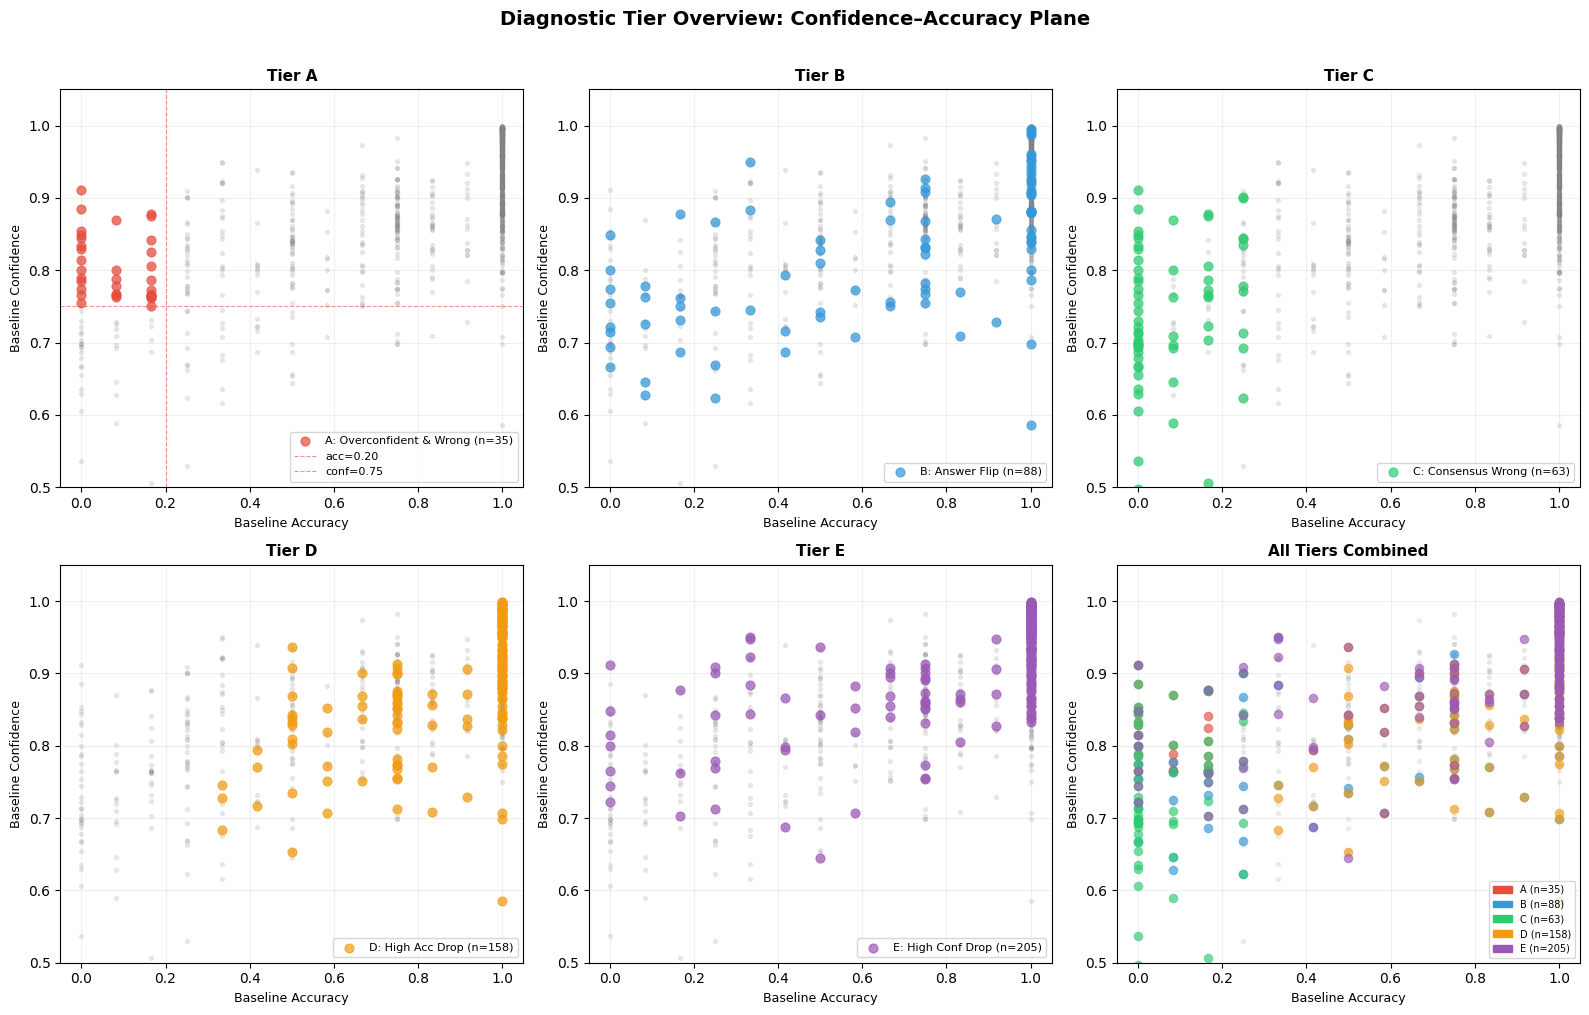

Spatial patterns in the confidence–accuracy plane:
  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone
  Tier C (green):  Left cluster — all models wrong, regardless of confidence level
  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

FIGURES_DIR = '/home/david/Desktop/yuna/HPA/analysis/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

tier_info = {
    'A': {'mask': qdf['overconfident_wrong'],          'color': '#e74c3c', 'label': 'A: Overconfident & Wrong'},
    'B': {'mask': qdf['mean_output_changes'] > 2,      'color': '#3498db', 'label': 'B: Answer Flip'},
    'C': {'mask': qdf['consensus_wrong'],               'color': '#2ecc71', 'label': 'C: Consensus Wrong'},
    'D': {'mask': qdf['acc_drop'] > 0.3,               'color': '#f39c12', 'label': 'D: High Acc Drop'},
    'E': {'mask': qdf['conf_drop'] > 0.05,             'color': '#9b59b6', 'label': 'E: High Conf Drop'},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Diagnostic Tier Overview: Confidence–Accuracy Plane', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, (tier_key, info) in enumerate(tier_info.items()):
    ax = axes_flat[idx]
    # Background: all 1K questions
    ax.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.15, color='gray', zorder=1)
    # Highlighted tier
    subset = qdf[info['mask']]
    ax.scatter(subset['acc_baseline'], subset['conf_baseline'],
               s=40, alpha=0.7, color=info['color'], zorder=2,
               label=f"{info['label']} (n={len(subset)})")
    # Tier A thresholds
    if tier_key == 'A':
        ax.axvline(0.2, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='acc=0.20')
        ax.axhline(0.75, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='conf=0.75')
    ax.set_xlabel('Baseline Accuracy', fontsize=9)
    ax.set_ylabel('Baseline Confidence', fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'Tier {tier_key}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

# Combined panel
ax_all = axes_flat[5]
ax_all.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.12, color='gray', zorder=1)
handles = []
for tier_key, info in tier_info.items():
    subset = qdf[info['mask']]
    ax_all.scatter(subset['acc_baseline'], subset['conf_baseline'],
                   s=35, alpha=0.6, color=info['color'], zorder=2)
    handles.append(mpatches.Patch(color=info['color'], label=f"{info['label'].split(':')[0]} (n={len(subset)})"))
ax_all.set_xlabel('Baseline Accuracy', fontsize=9)
ax_all.set_ylabel('Baseline Confidence', fontsize=9)
ax_all.set_xlim(-0.05, 1.05)
ax_all.set_ylim(0.5, 1.05)
ax_all.legend(handles=handles, fontsize=7, loc='lower right')
ax_all.set_title('All Tiers Combined', fontsize=11, fontweight='bold')
ax_all.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_overview_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spatial patterns in the confidence–accuracy plane:")
print("  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone")
print("  Tier C (green):  Left cluster — all models wrong, regardless of confidence level")
print("  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy")


In [33]:
# Helper functions (reused in subsequent cells)
def clean_q(s):
    s = str(s)
    for strip in ['Question: ', ' Answer the question using a single word or phrase.', '\nAnswer:']:
        s = s.replace(strip, '')
    s = s.strip()
    return s[:90] + ('\u2026' if len(s) > 90 else '')

MODEL_COLS = [c for c in ['Qwen3-VL-8B-Instruct', 'llava-1.5-7b-hf',
                            'llava-v1.6-mistral-7b-hf', 'llava-v1.6-vicuna-7b-hf']
              if c in review_df.columns]

def fmt_gt(gt):
    if isinstance(gt, list):
        unique = list(dict.fromkeys(str(a) for a in gt))
        return ', '.join(unique[:3]) + ('…' if len(unique) > 3 else '')
    return str(gt)[:40]

# Tier A: top 6 by confidence
tier_a_ids = [qid for qid in sampled_df[sampled_df['tiers'].str.contains('A_')]['question_id']
              if qid in review_df['question_id'].values]
tier_a_df = review_df[review_df['question_id'].isin(tier_a_ids)].copy()
tier_a_df = tier_a_df.sort_values('conf_baseline', ascending=False).head(6)

display_a = tier_a_df[['question_id', 'ent', 'conf_baseline', 'acc_baseline', 'question_text', 'gt_answer'] + MODEL_COLS].copy()
display_a['Q'] = display_a['question_text'].apply(clean_q)
display_a['GT (sample)'] = display_a['gt_answer'].apply(fmt_gt)
display_a = display_a[['question_id', 'ent', 'Q', 'GT (sample)', 'conf_baseline', 'acc_baseline'] + MODEL_COLS]

from IPython.display import display

styled = (display_a.style
    .background_gradient(subset=['conf_baseline'], cmap='Reds', vmin=0.5, vmax=1.0)
    .background_gradient(subset=['acc_baseline'], cmap='Greens', vmin=0.0, vmax=1.0)
    .format({'conf_baseline': '{:.3f}', 'acc_baseline': '{:.3f}'})
    .set_caption('Tier A — Overconfident & Wrong (top 6 by confidence)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight','bold'),('font-size','13px')]}])
)
display(styled)

print("\nInsight: High confidence + wrong answer = model is drawing on corpus statistics, not image content.")
print("In a blind/text-only evaluation, these questions expose the strongest hallucination bias.")


,question_id,ent,Q,GT (sample),conf_baseline,acc_baseline,Qwen3-VL-8B-Instruct,llava-1.5-7b-hf,llava-v1.6-mistral-7b-hf,llava-v1.6-vicuna-7b-hf
93,164330007,person,Do these people need refills?,no,0.912,0.000,yes,Yes,Yes,Yes
13,158279002,text,What is the web address listed?,"foodiebakercom, http://foodiebakercom",0.885,0.000,http://foodiebaker.com,Wwwfoodiebakercom,Wwwfoodiebakercom,Wwwfoodiebakercom
94,13546003,object,How many benches are in the background?,"4, 3, 0…",0.878,0.167,3,2,2,2
20,569274000,food,What flavor of jelly are the boys eating?,"orange, yellow, peach…",0.875,0.167,none,Grape,Strawberry,Grape
90,309843001,object,What is wrapped around the surfboards?,"ankle leash, cord, tree…",0.854,0.000,rope,Rope,Rope,Rope
1,13769009,place,What is this bathroom missing?,"door, sink, yes…",0.848,0.000,toilet paper,Toilet paper,Toilet paper,Toilet paper



Insight: High confidence + wrong answer = model is drawing on corpus statistics, not image content.
In a blind/text-only evaluation, these questions expose the strongest hallucination bias.


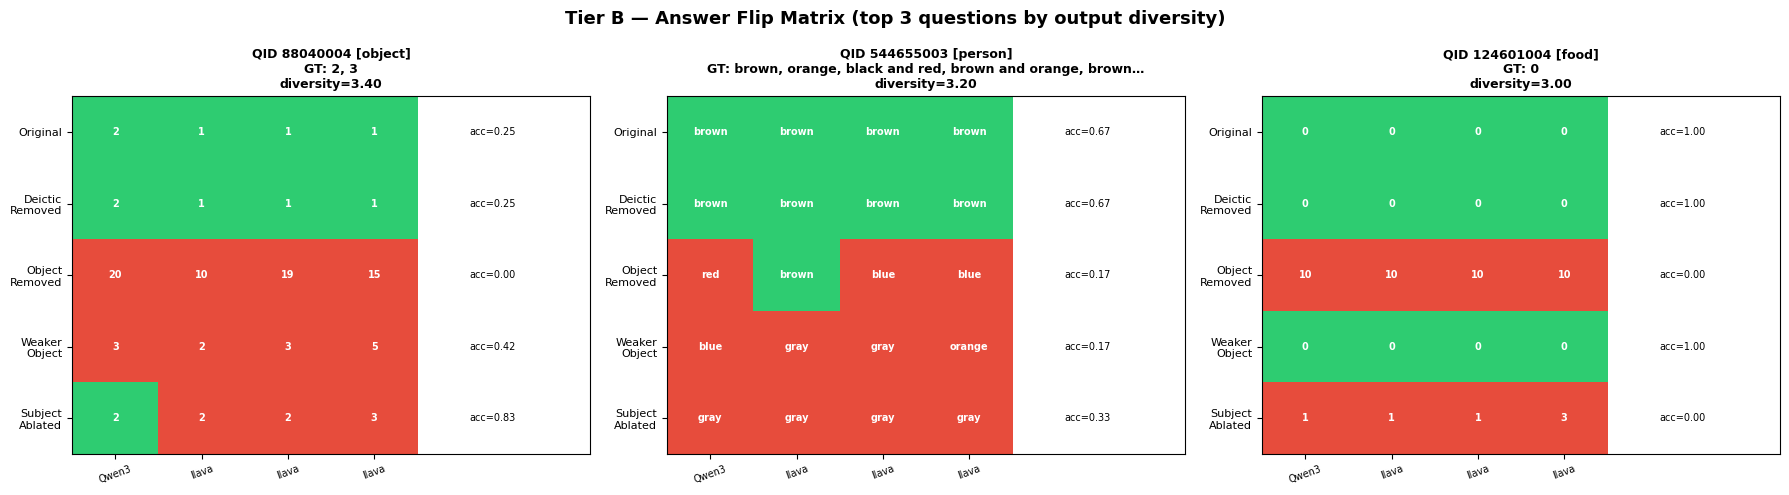

Insight: Answer changes when linguistic triggers are removed reveal that models respond
to question surface form, not semantic content. Green = matches baseline; red = flipped answer.


In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

CT_LABELS = {
    'question': 'Original',
    'deictic_removed': 'Deictic\nRemoved',
    'object_removed': 'Object\nRemoved',
    'weaker_object': 'Weaker\nObject',
    'subject_ablated': 'Subject\nAblated',
}

# Top 3 Tier B questions by mean_output_changes
tier_b_ids = sampled_df[sampled_df['tiers'].str.contains('B_')].sort_values(
    'mean_output_changes', ascending=False)['question_id'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tier B — Answer Flip Matrix (top 3 questions by output diversity)',
             fontsize=13, fontweight='bold')

for ax_idx, qid in enumerate(tier_b_ids):
    ax = axes[ax_idx]
    
    # Baseline answer (from review_df)
    baseline_row = review_df[review_df['question_id'] == qid].iloc[0]
    baseline_answers = {m: str(baseline_row.get(m, '')).lower().strip() for m in MODEL_COLS}
    
    # Per-variant outputs from df
    q_data = df[(df['question_id'] == qid) & (df['model'].isin(MODEL_COLS))].pivot_table(
        index='control_type', columns='model', values='output', aggfunc='first'
    ).reindex(CONTROL_TYPES)
    
    # Per-variant accuracy from agg
    acc_data = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    
    n_ct = len(CONTROL_TYPES)
    n_m  = len(MODEL_COLS)
    color_matrix = np.zeros((n_ct, n_m))
    text_matrix  = []
    
    for r, ct in enumerate(CONTROL_TYPES):
        row_texts = []
        for c, m in enumerate(MODEL_COLS):
            if ct in q_data.index and m in q_data.columns:
                val = str(q_data.loc[ct, m]).lower().strip() if pd.notna(q_data.loc[ct, m]) else ''
            else:
                val = ''
            base_ans = baseline_answers.get(m, '')
            color_matrix[r, c] = 1.0 if (val == base_ans and val != '') else 0.0
            row_texts.append(val[:8])
        text_matrix.append(row_texts)
    
    # Heatmap: green=matches baseline, red=different
    cmap = mcolors.LinearSegmentedColormap.from_list('flip', ['#e74c3c', '#2ecc71'])
    ax.imshow(color_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    
    for r in range(n_ct):
        for c in range(n_m):
            ax.text(c, r, text_matrix[r][c], ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
        # Right-margin acc annotation
        acc_val = acc_data.iloc[r] if r < len(acc_data) else float('nan')
        ax.text(n_m + 0.1, r, f'acc={acc_val:.2f}' if pd.notna(acc_val) else 'acc=N/A',
                va='center', fontsize=7, color='black')
    
    ax.set_xticks(range(n_m))
    ax.set_xticklabels([m.split('-')[0][:12] for m in MODEL_COLS], fontsize=7, rotation=20)
    ax.set_yticks(range(n_ct))
    ax.set_yticklabels([CT_LABELS[ct] for ct in CONTROL_TYPES], fontsize=8)
    ax.set_xlim(-0.5, n_m + 1.5)
    
    # Entity and GT
    row_info = sampled_df[sampled_df['question_id'] == qid].iloc[0]
    gt_sample = fmt_gt(baseline_row['gt_answer'])
    diversity = row_info['mean_output_changes']
    ax.set_title(f'QID {qid} [{row_info["ent"]}]\nGT: {gt_sample}\ndiversity={diversity:.2f}',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_b_flip_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Answer changes when linguistic triggers are removed reveal that models respond")
print("to question surface form, not semantic content. Green = matches baseline; red = flipped answer.")


ValueError: could not convert string to float: '100%'

All models converge on the same wrong answer → the correct answer is underrepresented
in training data for these visual patterns.



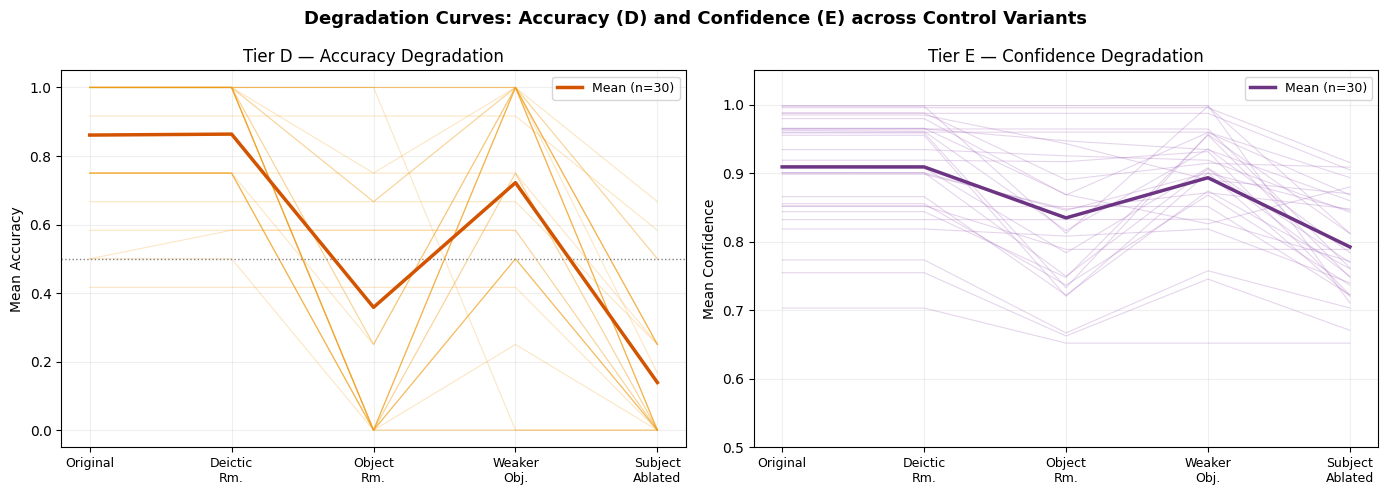

Tier D: When the specific object reference is removed, accuracy collapses → the model was
using the word 'clock'/'house' as a retrieval key, not the image.

Tier E: Confidence drops even when the answer stays correct → models 'know' the question
became harder, betraying sensitivity to surface cues over grounded understanding.


In [35]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

# ── Tier C: top 6 by frac_models_wrong ──────────────────────────────────────
tier_c_ids = sampled_df[sampled_df['tiers'].str.contains('C_')].sort_values(
    'frac_models_wrong', ascending=False)['question_id'].head(6).tolist()
tier_c_df = review_df[review_df['question_id'].isin(tier_c_ids)].copy()
tier_c_df = tier_c_df.sort_values('frac_models_wrong', ascending=False)

display_c = tier_c_df[['question_id', 'ent', 'question_text', 'gt_answer', 'frac_models_wrong'] + MODEL_COLS].copy()
display_c['Q'] = display_c['question_text'].apply(clean_q)
display_c['GT (sample)'] = display_c['gt_answer'].apply(fmt_gt)
display_c['% wrong'] = display_c['frac_models_wrong'].map('{:.0%}'.format)
display_c = display_c[['question_id', 'ent', 'Q', 'GT (sample)', '% wrong'] + MODEL_COLS]

styled_c = (display_c.style
    .background_gradient(subset=['% wrong'], cmap='Reds')
    .set_caption('Tier C — Cross-Model Consensus Wrong (top 6 by % models wrong)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight','bold'),('font-size','13px')]}])
)
display(styled_c)
print("All models converge on the same wrong answer → the correct answer is underrepresented")
print("in training data for these visual patterns.\n")

# ── Tier D & E: Degradation Curves ─────────────────────────────────────────
fig, (ax_d, ax_e) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Degradation Curves: Accuracy (D) and Confidence (E) across Control Variants',
             fontsize=13, fontweight='bold')

x = range(len(CONTROL_TYPES))
x_labels = ['Original', 'Deictic\nRm.', 'Object\nRm.', 'Weaker\nObj.', 'Subject\nAblated']

# Tier D — accuracy
tier_d_ids = sampled_df[sampled_df['tiers'].str.contains('D_')]['question_id'].tolist()
tier_d_curves = []
for qid in tier_d_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_d_curves.append(q_agg.values)
        ax_d.plot(x, q_agg.values, color='#f39c12', alpha=0.25, linewidth=0.8)

if tier_d_curves:
    mean_d = np.nanmean(tier_d_curves, axis=0)
    ax_d.plot(x, mean_d, color='#d35400', linewidth=2.5, label=f'Mean (n={len(tier_d_curves)})', zorder=5)
ax_d.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax_d.set_xticks(list(x))
ax_d.set_xticklabels(x_labels, fontsize=9)
ax_d.set_ylabel('Mean Accuracy')
ax_d.set_ylim(-0.05, 1.05)
ax_d.set_title('Tier D — Accuracy Degradation')
ax_d.legend(fontsize=9)
ax_d.grid(True, alpha=0.2)

# Tier E — confidence
tier_e_ids = sampled_df[sampled_df['tiers'].str.contains('E_')]['question_id'].tolist()
tier_e_curves = []
for qid in tier_e_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_confidence'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_e_curves.append(q_agg.values)
        ax_e.plot(x, q_agg.values, color='#9b59b6', alpha=0.25, linewidth=0.8)

if tier_e_curves:
    mean_e = np.nanmean(tier_e_curves, axis=0)
    ax_e.plot(x, mean_e, color='#6c3483', linewidth=2.5, label=f'Mean (n={len(tier_e_curves)})', zorder=5)
ax_e.set_xticks(list(x))
ax_e.set_xticklabels(x_labels, fontsize=9)
ax_e.set_ylabel('Mean Confidence')
ax_e.set_ylim(0.5, 1.05)
ax_e.set_title('Tier E — Confidence Degradation')
ax_e.legend(fontsize=9)
ax_e.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_d_e_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tier D: When the specific object reference is removed, accuracy collapses → the model was")
print("using the word 'clock'/'house' as a retrieval key, not the image.")
print()
print("Tier E: Confidence drops even when the answer stays correct → models 'know' the question")
print("became harder, betraying sensitivity to surface cues over grounded understanding.")


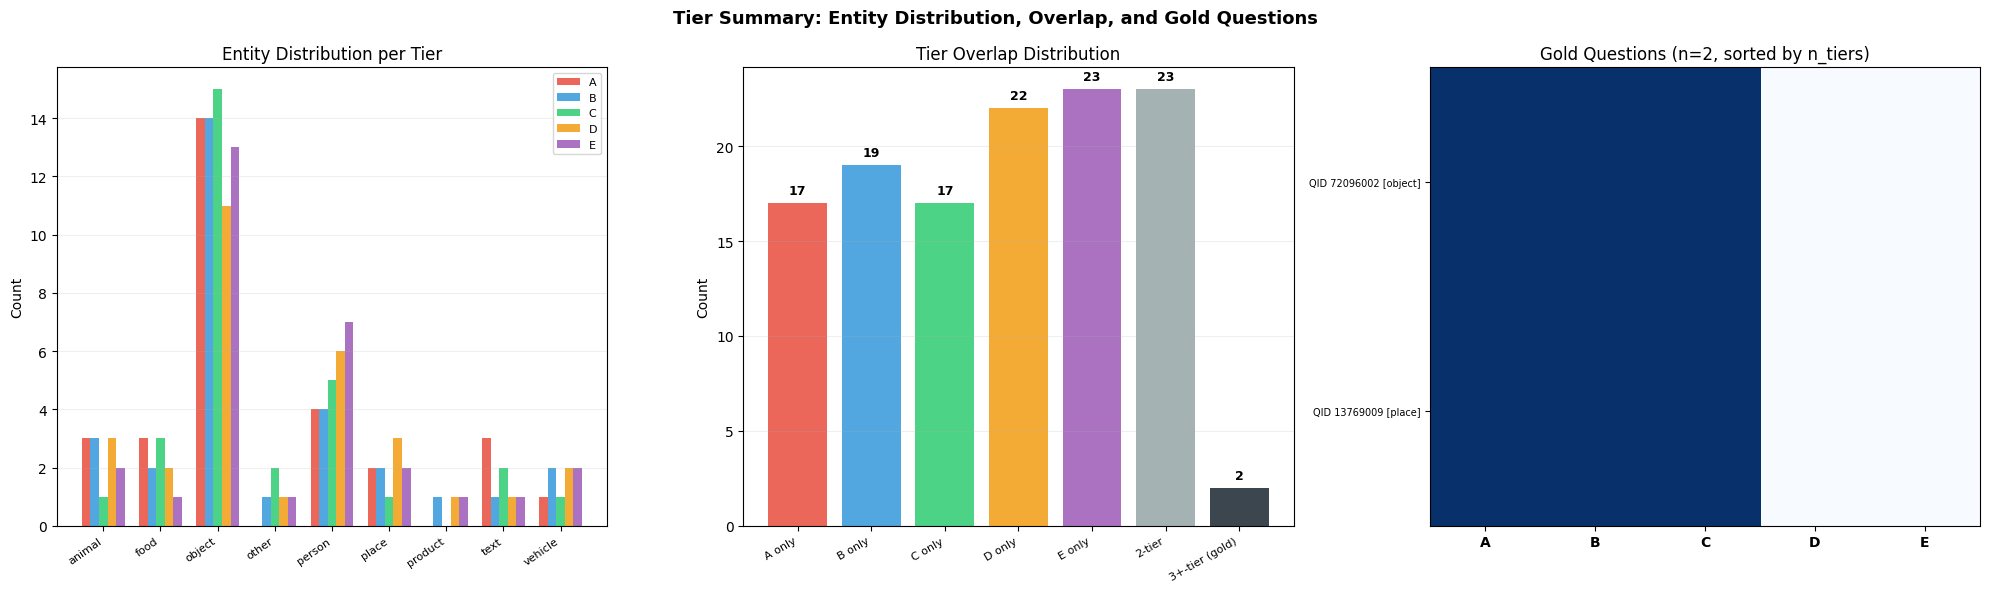

Gold questions (3+ tiers): 2
Gold questions should be prioritized for the human study — they simultaneously probe
multiple failure modes and provide the richest signal about whether humans share the
model's biases.


In [36]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

TIER_KEYS  = ['A', 'B', 'C', 'D', 'E']
TIER_NAMES = {'A': 'A_overconfident_wrong', 'B': 'B_answer_flip', 'C': 'C_consensus_wrong',
              'D': 'D_high_acc_drop', 'E': 'E_high_conf_drop'}
TIER_COLORS = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71', 'D': '#f39c12', 'E': '#9b59b6'}
ENT_CATS   = sorted(qdf['ent'].dropna().unique())

# ── Entity distribution per tier ─────────────────────────────────────────────
tier_ent = {}
for t in TIER_KEYS:
    name = TIER_NAMES[t]
    ids = sampled_df[sampled_df['tiers'].str.contains(name)]['question_id'].tolist()
    sub = sampled_df[sampled_df['question_id'].isin(ids)]
    tier_ent[t] = sub['ent'].value_counts().reindex(ENT_CATS, fill_value=0)

# ── Tier overlap ──────────────────────────────────────────────────────────────
overlap_counts = {'A only': 0, 'B only': 0, 'C only': 0, 'D only': 0, 'E only': 0,
                  '2-tier': 0, '3+-tier (gold)': 0}
for _, row in sampled_df.iterrows():
    n = row['n_tiers']
    if n == 1:
        t = row['tiers'].split('_')[0]
        overlap_counts[f'{t} only'] += 1
    elif n == 2:
        overlap_counts['2-tier'] += 1
    else:
        overlap_counts['3+-tier (gold)'] += 1

# ── Gold questions ────────────────────────────────────────────────────────────
gold_df = sampled_df[sampled_df['n_tiers'] >= 3].sort_values('n_tiers', ascending=False).head(20)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Tier Summary: Entity Distribution, Overlap, and Gold Questions',
             fontsize=13, fontweight='bold')

# Left — grouped bar chart
bar_width = 0.15
ent_x = np.arange(len(ENT_CATS))
for i, t in enumerate(TIER_KEYS):
    ax1.bar(ent_x + i * bar_width, tier_ent[t].values, width=bar_width,
            label=t, color=TIER_COLORS[t], alpha=0.85)
ax1.set_xticks(ent_x + bar_width * 2)
ax1.set_xticklabels(ENT_CATS, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Count')
ax1.set_title('Entity Distribution per Tier')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.2)

# Middle — tier overlap bars
bar_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#95a5a6','#1a252f']
bars = ax2.bar(range(len(overlap_counts)), list(overlap_counts.values()),
               color=bar_colors, alpha=0.85)
for bar, val in zip(bars, overlap_counts.values()):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(overlap_counts)))
ax2.set_xticklabels(list(overlap_counts.keys()), rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Count')
ax2.set_title('Tier Overlap Distribution')
ax2.grid(True, axis='y', alpha=0.2)

# Right — gold question heatmap
tier_binary = np.zeros((len(gold_df), len(TIER_KEYS)))
for r_idx, (_, row) in enumerate(gold_df.iterrows()):
    for c_idx, t in enumerate(TIER_KEYS):
        if TIER_NAMES[t] in row['tiers']:
            tier_binary[r_idx, c_idx] = 1.0

ax3.imshow(tier_binary, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(TIER_KEYS)))
ax3.set_xticklabels(TIER_KEYS, fontsize=10, fontweight='bold')
ytick_labels = [f"QID {row['question_id']} [{row['ent']}]"
                for _, row in gold_df.iterrows()]
ax3.set_yticks(range(len(gold_df)))
ax3.set_yticklabels(ytick_labels, fontsize=7)
ax3.set_title(f'Gold Questions (n={len(gold_df)}, sorted by n_tiers)')
ax3.grid(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_summary.png', dpi=150, bbox_inches='tight')
plt.show()

gold_count = overlap_counts['3+-tier (gold)']
print(f"Gold questions (3+ tiers): {gold_count}")
print("Gold questions should be prioritized for the human study — they simultaneously probe")
print("multiple failure modes and provide the richest signal about whether humans share the")
print("model's biases.")


In [37]:
# Export for manual review / human study design
out_path = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
review_df.to_csv(out_path, index=False)
print(f'Saved {len(review_df)} questions to {out_path}') 

Saved 123 questions to /home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv
